In [1]:
#导包：公共数据包
import csv
import pandas as pd
import time
import json
import numpy as np
from shapely.geometry import LineString
import os
import datetime
#导包：自有包
from utils import util as util
from douglas_peucker import DouglasPeuker
from utils import visualization as visual

In [2]:
# 需要调整的阈值
LIMIT_LENGTH = 65  # 轨迹长度小于该值的将被过滤掉
LIMIT_POINT = 5  # 轨迹点数小于该值的将被过滤掉
LIMIT_DT = 30  # 时间戳间隔大于该值的将被分段 3 * 平均采样间隔（10s）
LIMIT_DISTANCE = 400  # 距离大于该值的将被分段 2 * 平均采样间隔（10s）* 城市限速（20m/s）
LIMIT_DIRECTION = 35  # 方向变换大于该值的将去噪
DP_THRESHOLD = 5  # 道格拉斯-普克 阈值

In [3]:
# 调用道格拉斯-普克算法，减少轨迹点索引，轨迹抽稀
def get_reduction_traj_index(coordinates):
    traj_mercator = util.transform_points_wgs84_to_mercator(coordinates)
    result_index = []
    d = DouglasPeuker(DP_THRESHOLD)
    d.reduction(traj_mercator)
    temp_list = d.qualify_list
    for i, item in enumerate(traj_mercator):
        if item in temp_list:
            result_index.append(i)
    return result_index  # 抽稀后的坐标点索引

# 计算速度和方向
def calculate_speed_and_dir(traj):
    result = dict()
    for key, value in traj.items():
        directions = util.get_direction(value[1])
        velocities = util.get_velocity(value[1], value[0])
        result[key] = [value[0], value[1], velocities, directions]
    return result

## 1.完成轨迹分段代码实现

In [4]:
# 轨迹分段 
def split_traj(traj):  # traj {'id':[[时间戳],[坐标点]]}
    res = {}
    # 待填充
    return res

## 2.完成轨迹去噪代码实现

In [5]:
# 轨迹去噪
def denoise_traj(traj):  # traj {'id':[[时间戳],[坐标点],[方向],[速度]]}
    res = {}
    # 待填充
    return res

## 3.完成轨迹简化代码实现

In [6]:
## 3.完成轨迹简化代码实现# 轨迹去噪
def simplify_traj(traj):  # traj {'id':[[时间戳],[坐标点],[方向],[速度]]}
    res = {}
    # 待填充
    return res

## 4.主函数

In [7]:
traj_dict = json.load(open('traj_dict.json'))
tra_split = split_traj(traj_dict)
tra_denoise = denoise_traj(tra_split)
tra_simplify = simplify_traj(tra_denoise)

In [8]:
traj_dict['0']

[[1523293209,
  1523293229,
  1523293240,
  1523293249,
  1523293259,
  1523293270,
  1523293289,
  1523293310,
  1523293311,
  1523293319,
  1523293329,
  1523293349,
  1523293359,
  1523293369,
  1523293379,
  1523293389,
  1523293409,
  1523293419,
  1523293429,
  1523293439,
  1523293449,
  1523293469,
  1523293479,
  1523293489,
  1523293499,
  1523293509,
  1523293529,
  1523293539,
  1523293549,
  1523293559,
  1523293569,
  1523293589,
  1523293599,
  1523293609,
  1523293619,
  1523293629,
  1523293649,
  1523293659,
  1523293669,
  1523293679,
  1523293689,
  1523293709,
  1523293719,
  1523293729,
  1523293739,
  1523293749,
  1523293769,
  1523293779,
  1523293789,
  1523293799,
  1523293809,
  1523293829,
  1523293839,
  1523293849,
  1523293859,
  1523293869,
  1523293889,
  1523293899,
  1523293909,
  1523293919,
  1523293929,
  1523293949,
  1523293959,
  1523293969,
  1523293979,
  1523293989,
  1523294009,
  1523294019,
  1523294029,
  1523294039,
  1523294049,
  1523

##### 5.轨迹分段超参数实验（提示：距离、时间阈值对分段后剩余轨迹点数量的影响）选做

##### 6.轨迹去噪超参数实验 选做

##### 7.轨迹简化超参数实验 选做

D:\anaconda\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29616 (\N{CJK UNIFIED IDEOGRAPH-73B0}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda\lib\site-packages\IPython\core\pylabtools.p

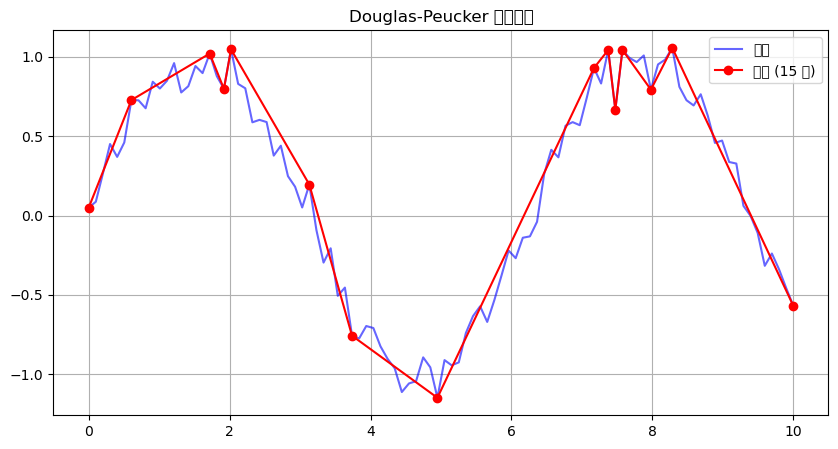

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def douglas_peucker(points, epsilon):
    """
    Douglas-Peucker 算法
    :param points: 点列表，shape (n, 2)
    :param epsilon: 阈值，越大越简化
    :return: 简化后的点列表
    """
    points = np.array(points)  # ✅ 强制转 array

    # 找到离首尾连线最远的点
    start_point = points[0]
    end_point = points[-1]
    
    # 向量
    vec = end_point - start_point
    line_len = np.linalg.norm(vec)
    
    if line_len == 0:
        return [start_point]
    
    # 单位向量
    unit_vec = vec / line_len
    
    # 计算每个点到线段的距离
    seg_vec = points - start_point
    proj_lengths = np.dot(seg_vec, unit_vec)
    proj_points = start_point + proj_lengths[:, np.newaxis] * unit_vec
    
    distances = np.linalg.norm(points - proj_points, axis=1)
    max_dist = np.max(distances)
    max_idx = np.argmax(distances)
    
    if max_dist > epsilon:
        # 递归处理两段
        left = douglas_peucker(points[:max_idx+1], epsilon)
        right = douglas_peucker(points[max_idx:], epsilon)
        # 合并，去重中间点
        return left[:-1] + right
    else:
        return [start_point, end_point]

# 使用示例
np.random.seed(42)
x = np.linspace(0, 10, 100)
y = np.sin(x) + 0.1 * np.random.randn(100)
points = np.column_stack((x, y))

simplified = douglas_peucker(points.tolist(), epsilon=0.2)
simplified = np.array(simplified)

# 可视化
plt.figure(figsize=(10, 5))
plt.plot(points[:, 0], points[:, 1], 'b-', label='orig', alpha=0.6)
plt.plot(simplified[:, 0], simplified[:, 1], 'ro-', label=f'simply ({len(simplified)} point)')
plt.legend()
plt.title('Douglas-Peucker ')
plt.grid(True)
plt.show()